All libraries loaded successfully.
Please upload your gene_motif_model_matrix_2kb.csv file:


Saving gene_motif_model_matrix_2kb.csv to gene_motif_model_matrix_2kb.csv

Dataset shape : (10785, 734)
Genes         : 10785
Motif columns : 732  (excluding Gene & FPKM)

First 5 rows:
X shape : (10785, 732)
y shape : (10785,)

FPKM stats (raw):
count    10785.000
mean        75.897
std        354.748
min          0.000
25%          3.323
50%         14.437
75%         47.961
max      18081.055
Name: FPKM, dtype: float64

log(1+FPKM) stats:
count    10785.000
mean         2.757
std          1.659
min          0.000
25%          1.464
50%          2.737
75%          3.891
max          9.803
dtype: float64
Top 10 positively correlated motifs:
MA0095.4_Yy1             0.1688
MA1651.2_ZFP42           0.1541
MA0517.2_STAT1::STAT2    0.1538
MA0606.3_Nfat5           0.1340
MA0748.3_YY2             0.1337
MA0050.4_Irf1            0.1320
MA0598.4_EHF             0.1305
MA0629.2_Rhox11          0.1301
MA0497.2_MEF2C           0.1298
MA1623.2_Stat2           0.1293
Name: pearson_r, dtype: float6

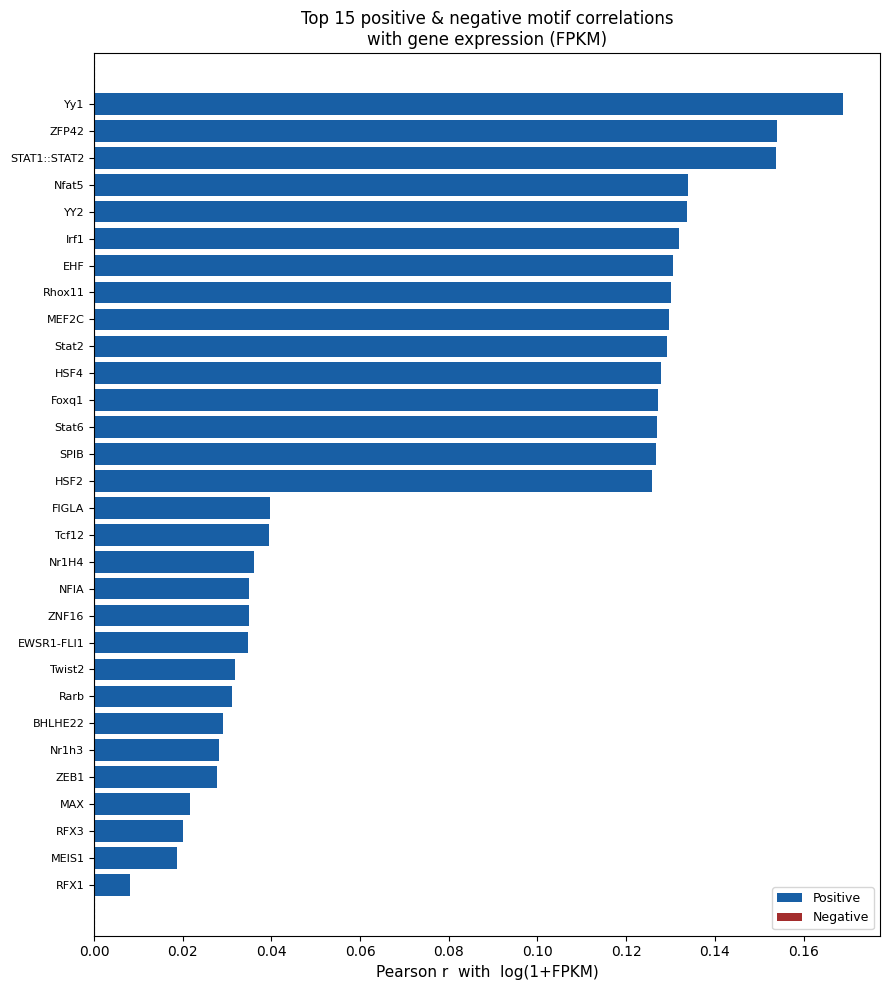

Saved: motif_correlations.png


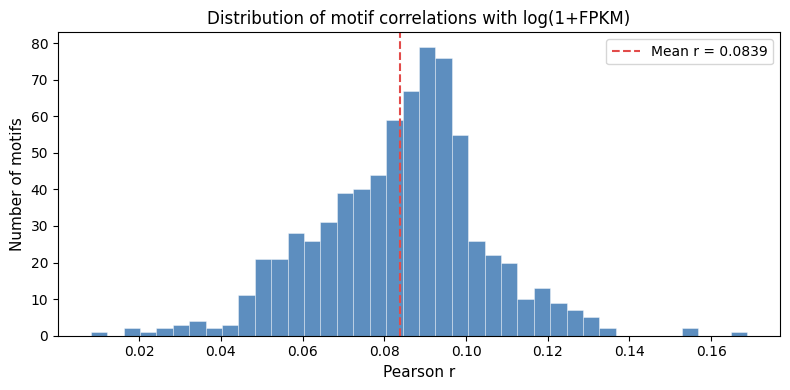

Saved: correlation_distribution.png
Training set : 8628 genes
Test set     : 2157 genes
  Lasso Regression Results  (alpha=0.01)
  Train R²         : 0.1840
  Test  R²         : 0.1437
  Train RMSE       : 1.5034  (log scale)
  Test  RMSE       : 1.5167  (log scale)
  Train Pearson r  : 0.4332  (p=0.00e+00)
  Test  Pearson r  : 0.3791  (p=1.09e-74)
  Non-zero motifs  : 333 / 732
5-fold CV R² scores : [0.1059 0.1117 0.1041 0.0799 0.1056]
Mean CV R²          : 0.1015 ± 0.0111


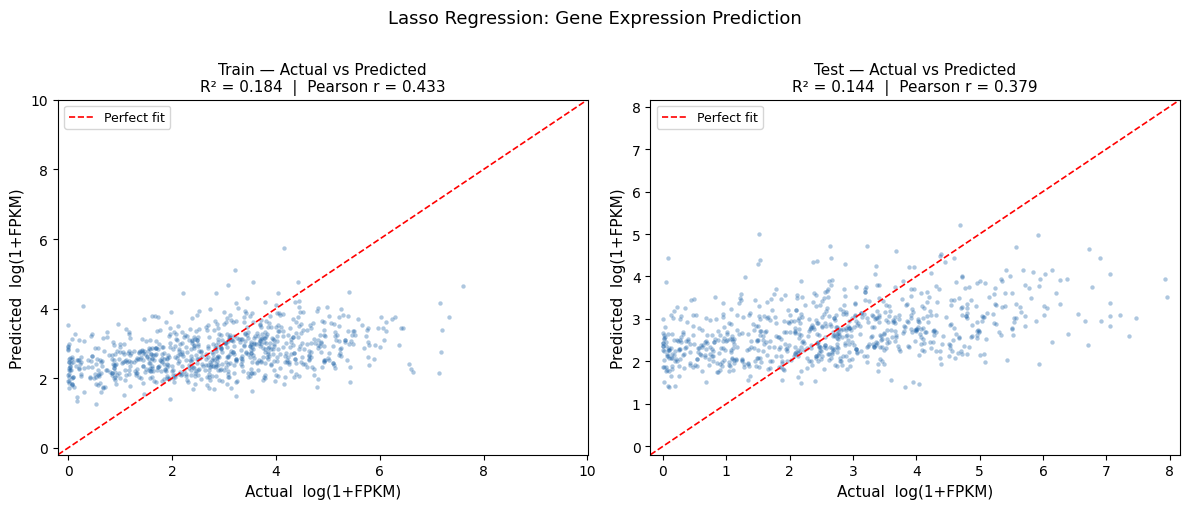

Saved: actual_vs_predicted.png

Lasso selected 333 motifs out of 732


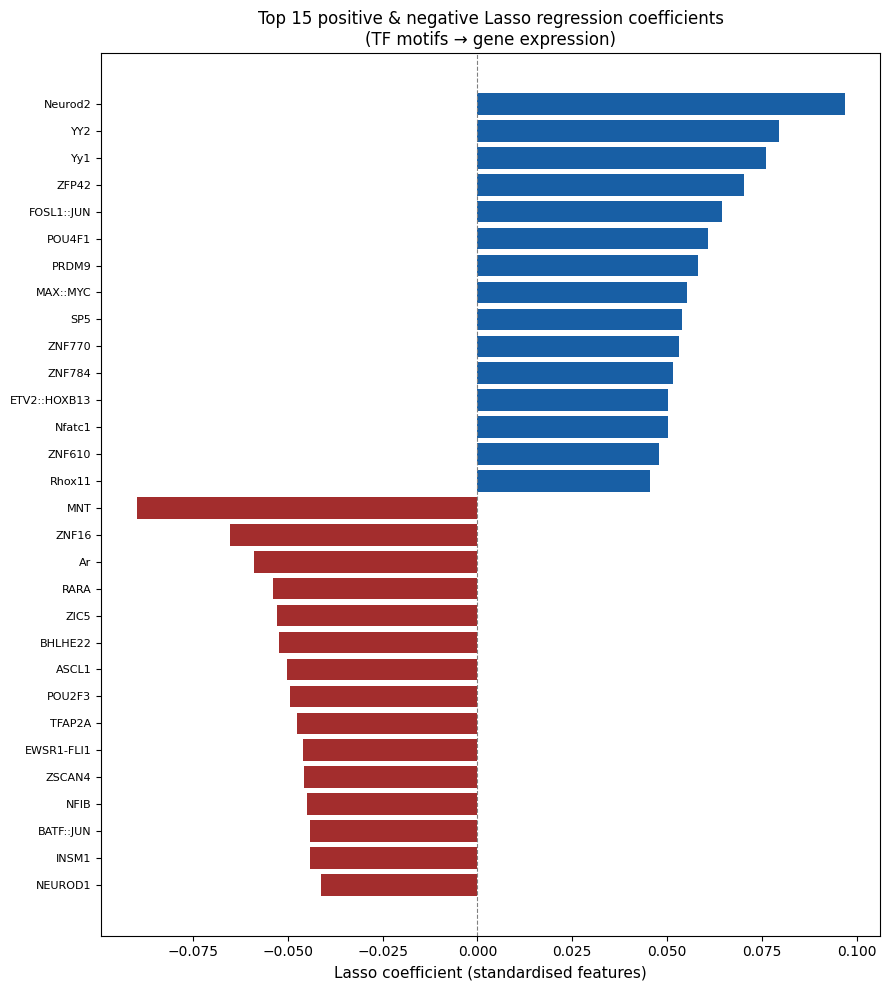

Saved: lasso_coefficients.png


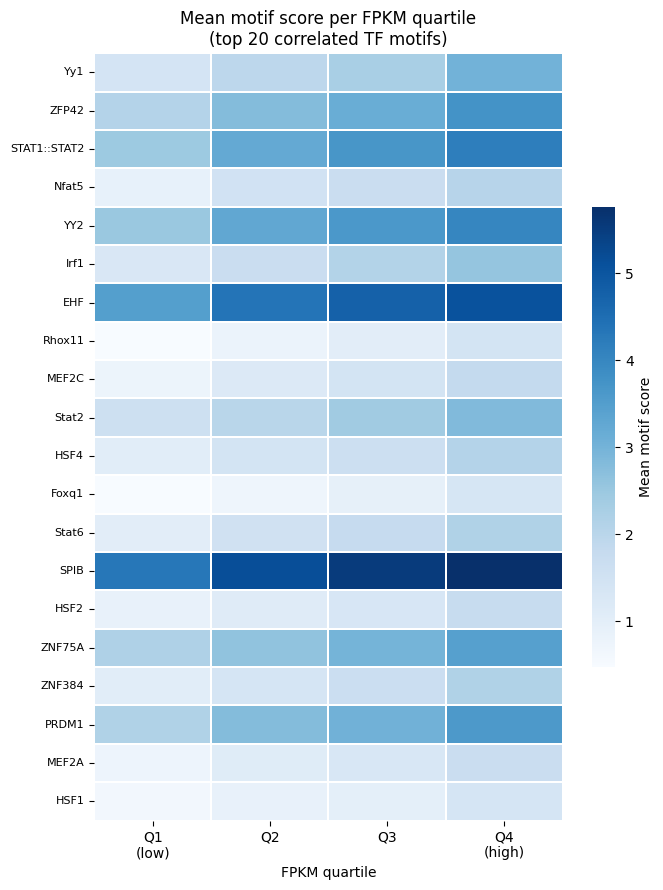

Saved: heatmap_motif_vs_quartile.png
Exported:
  motif_correlations.csv
  lasso_coefficients.csv
  lasso_model_metrics.csv

All done! Download files from the Colab file browser (left panel).


In [1]:
# ============================================================
# Gene Expression Modelling from TF Motif Scores — LASSO
# Google Colab Notebook
# ============================================================
# Run each cell in order inside Google Colab.
# Upload your gene_motif_model_matrix_2kb.csv when prompted in Cell 2.
# ============================================================


# ── Cell 1: Install & import libraries ──────────────────────
# (Most are pre-installed in Colab; seaborn may need upgrade)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

print("All libraries loaded successfully.")


# ── Cell 2: Upload & load the CSV ───────────────────────────

from google.colab import files

print("Please upload your gene_motif_model_matrix_2kb.csv file:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f"\nDataset shape : {df.shape}")
print(f"Genes         : {df.shape[0]}")
print(f"Motif columns : {df.shape[1] - 2}  (excluding Gene & FPKM)")
print("\nFirst 5 rows:")
df.head()


# ── Cell 3: Prepare X and y ─────────────────────────────────

motif_cols = [c for c in df.columns if c not in ["Gene", "FPKM"]]

X = df[motif_cols].values                  # shape: (n_genes, n_motifs)
y_raw = df["FPKM"].values                  # raw FPKM
y = np.log1p(y_raw)                        # log-transform: stabilises variance

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"\nFPKM stats (raw):")
print(df["FPKM"].describe().round(3))
print(f"\nlog(1+FPKM) stats:")
print(pd.Series(y).describe().round(3))


# ── Cell 4: Correlation of each motif with log(FPKM) ────────

corr = pd.Series(
    [stats.pearsonr(df[col], y)[0] for col in motif_cols],
    index=motif_cols,
    name="pearson_r"
)

corr_sorted = corr.sort_values(ascending=False)

print("Top 10 positively correlated motifs:")
print(corr_sorted.head(10).round(4))
print("\nTop 10 negatively correlated motifs:")
print(corr_sorted.tail(10).round(4))


# ── Cell 5: Plot – Top 30 motif correlations (bar chart) ────

top15  = corr_sorted.head(15)
bot15  = corr_sorted.tail(15)
plot_corr = pd.concat([top15, bot15])

tf_labels = [m.split("_", 1)[1] for m in plot_corr.index]  # strip MA#### prefix
bar_colors = ["#185FA5" if v >= 0 else "#A32D2D" for v in plot_corr.values]

fig, ax = plt.subplots(figsize=(9, 10))
bars = ax.barh(tf_labels, plot_corr.values, color=bar_colors, edgecolor="none")
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Pearson r  with  log(1+FPKM)", fontsize=11)
ax.set_title("Top 15 positive & negative motif correlations\nwith gene expression (FPKM)", fontsize=12)
ax.invert_yaxis()
ax.tick_params(axis="y", labelsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#185FA5", label="Positive"),
                   Patch(facecolor="#A32D2D", label="Negative")]
ax.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig("motif_correlations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: motif_correlations.png")


# ── Cell 6: Plot – Correlation distribution (histogram) ─────

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(corr.values, bins=40, color="#185FA5", alpha=0.7, edgecolor="white", linewidth=0.4)
ax.axvline(corr.mean(), color="#E24B4A", linewidth=1.5, linestyle="--",
           label=f"Mean r = {corr.mean():.4f}")
ax.set_xlabel("Pearson r", fontsize=11)
ax.set_ylabel("Number of motifs", fontsize=11)
ax.set_title("Distribution of motif correlations with log(1+FPKM)", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("correlation_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: correlation_distribution.png")


# ── Cell 7: Train/test split & feature scaling ───────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training set : {X_train_s.shape[0]} genes")
print(f"Test set     : {X_test_s.shape[0]} genes")


# ── Cell 8: Lasso regression model ──────────────────────────

lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_train_s, y_train)

y_pred_train = lasso.predict(X_train_s)
y_pred_test  = lasso.predict(X_test_s)

# ── R² ──────────────────────────────────────────────────────
r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test,  y_pred_test)

# ── RMSE ────────────────────────────────────────────────────
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))

# ── Pearson r ────────────────────────────────────────────────
pearson_train, pval_train = stats.pearsonr(y_train, y_pred_train)
pearson_test,  pval_test  = stats.pearsonr(y_test,  y_pred_test)

# ── Non-zero coefficients (Lasso feature selection) ──────────
n_nonzero = np.sum(lasso.coef_ != 0)

print("=" * 50)
print(f"  Lasso Regression Results  (alpha=0.01)")
print("=" * 50)
print(f"  Train R²         : {r2_train:.4f}")
print(f"  Test  R²         : {r2_test:.4f}")
print(f"  Train RMSE       : {rmse_train:.4f}  (log scale)")
print(f"  Test  RMSE       : {rmse_test:.4f}  (log scale)")
print(f"  Train Pearson r  : {pearson_train:.4f}  (p={pval_train:.2e})")
print(f"  Test  Pearson r  : {pearson_test:.4f}  (p={pval_test:.2e})")
print(f"  Non-zero motifs  : {n_nonzero} / {len(lasso.coef_)}")
print("=" * 50)


# ── Cell 9: 5-fold cross-validation ─────────────────────────

cv_scores = cross_val_score(
    Lasso(alpha=0.01, max_iter=10000),
    scaler.fit_transform(X), y,
    cv=5, scoring="r2"
)

print(f"5-fold CV R² scores : {np.round(cv_scores, 4)}")
print(f"Mean CV R²          : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


# ── Cell 10: Plot – Actual vs Predicted (scatter) ───────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, act, pred, split, r2, pr in [
    (axes[0], y_train, y_pred_train, "Train", r2_train, pearson_train),
    (axes[1], y_test,  y_pred_test,  "Test",  r2_test,  pearson_test),
]:
    np.random.seed(42)
    idx = np.random.choice(len(act), min(800, len(act)), replace=False)
    ax.scatter(act[idx], pred[idx], alpha=0.35, s=10,
               color="#185FA5", linewidths=0)
    lim = [min(act.min(), pred.min()) - 0.2,
           max(act.max(), pred.max()) + 0.2]
    ax.plot(lim, lim, "r--", linewidth=1.2, label="Perfect fit")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Actual  log(1+FPKM)", fontsize=11)
    ax.set_ylabel("Predicted  log(1+FPKM)", fontsize=11)
    ax.set_title(f"{split} — Actual vs Predicted\nR² = {r2:.3f}  |  Pearson r = {pr:.3f}",
                 fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle("Lasso Regression: Gene Expression Prediction", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: actual_vs_predicted.png")


# ── Cell 11: Top predictive TF motifs by Lasso coefficient ──

coef_series = pd.Series(lasso.coef_, index=motif_cols)

# Only non-zero motifs (Lasso performs built-in feature selection)
nonzero_coef = coef_series[coef_series != 0]
print(f"\nLasso selected {len(nonzero_coef)} motifs out of {len(coef_series)}")

top_coef = pd.concat([
    nonzero_coef.sort_values(ascending=False).head(15),
    nonzero_coef.sort_values(ascending=True).head(15)
])

tf_labels_coef = [m.split("_", 1)[1] for m in top_coef.index]
coef_colors = ["#185FA5" if v >= 0 else "#A32D2D" for v in top_coef.values]

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(tf_labels_coef, top_coef.values, color=coef_colors, edgecolor="none")
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Lasso coefficient (standardised features)", fontsize=11)
ax.set_title("Top 15 positive & negative Lasso regression coefficients\n"
             "(TF motifs → gene expression)", fontsize=12)
ax.invert_yaxis()
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig("lasso_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lasso_coefficients.png")


# ── Cell 12: Heatmap – top 20 motifs vs FPKM quartiles ──────

top20_motifs = corr_sorted.head(20).index.tolist()

df["fpkm_quartile"] = pd.qcut(df["FPKM"], q=4,
                               labels=["Q1\n(low)", "Q2", "Q3", "Q4\n(high)"])

heatmap_data = (
    df.groupby("fpkm_quartile")[top20_motifs]
      .mean()
      .T
)
heatmap_data.index = [i.split("_", 1)[1] for i in heatmap_data.index]

fig, ax = plt.subplots(figsize=(7, 9))
sns.heatmap(
    heatmap_data, cmap="Blues", ax=ax,
    linewidths=0.3, linecolor="white",
    cbar_kws={"label": "Mean motif score", "shrink": 0.6}
)
ax.set_title("Mean motif score per FPKM quartile\n(top 20 correlated TF motifs)", fontsize=12)
ax.set_xlabel("FPKM quartile", fontsize=10)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig("heatmap_motif_vs_quartile.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: heatmap_motif_vs_quartile.png")


# ── Cell 13: Export results ──────────────────────────────────

# Correlation table
corr_df = corr_sorted.reset_index()
corr_df.columns = ["motif", "pearson_r"]
corr_df["tf_name"] = corr_df["motif"].str.split("_", n=1).str[1]
corr_df.to_csv("motif_correlations.csv", index=False)

# Lasso coefficient table (all motifs, sorted by absolute value)
coef_df = coef_series.reset_index()
coef_df.columns = ["motif", "lasso_coef"]
coef_df["tf_name"] = coef_df["motif"].str.split("_", n=1).str[1]
coef_df = coef_df.sort_values("lasso_coef", key=abs, ascending=False)
coef_df.to_csv("lasso_coefficients.csv", index=False)

# Summary metrics table
metrics = {
    "Metric": [
        "Train R²", "Test R²",
        "Train RMSE (log scale)", "Test RMSE (log scale)",
        "Train Pearson r", "Test Pearson r",
        "Non-zero motifs selected"
    ],
    "Value": [
        round(r2_train, 4), round(r2_test, 4),
        round(rmse_train, 4), round(rmse_test, 4),
        round(pearson_train, 4), round(pearson_test, 4),
        int(n_nonzero)
    ]
}
pd.DataFrame(metrics).to_csv("lasso_model_metrics.csv", index=False)

print("Exported:")
print("  motif_correlations.csv")
print("  lasso_coefficients.csv")
print("  lasso_model_metrics.csv")
print("\nAll done! Download files from the Colab file browser (left panel).")